Análise de Desempenho de Algoritmo k-NN na Predição de Doença Renal Crônica 
=====================================

**Entrega escolhida:** Criatura Lendária "Cubo Gelatinoso" <br>
**Autoria:** Giovanna Avellar Machado <br>
**Disciplina:** Aprendizado de Máquina - 2º Semestre - T26 <br>
**Docente Responsável:** Daniel Roberto Cassar <br>
**Instituição:** Ilum - Escola de Ciência

## Índice

1. [Introdução](#intro)
2. [Metodologia](#metodologia)
3. [Desenvolvimento](#desenvolvimento) <br>
   3.1 [Pré-Processamento de Dados](#pre) <br>
   3.2 [Separação dos Dados de Treino e Teste](#sep) <br>
   3.3 [Escolha e Treino de um Modelo Preditivo](#escolha) <br>
   3.4 [Modelo de Classificação: Baseline](#base) <br>
   3.5 [Modeo de Classificação: k-vizinhos mais próximos](#knn) <br>
   3.6 [Métricas de Desempenho](#met) <br>
   3.7 [Variando os Hiperparâmetros](#hiper) <br> 
5. [Conclusões e Principais Aprendizados](#conclusao)
6. [Descrição do uso de IA neste trabalho](#interacao)
7. [Agradecimentos](#agradecimentos)
8. [Referências](#refs)

<a id="intro"></a>
## 1. Introdução

$ \ \ \ \ \ $ O presente trabalho busca estudar o desempenho de um modelo induzido pelo algoritmo dos k-vizinhos mais próximos (do inglês, k-NN, que significa k-Nearest Neighbors) em um conjunto de dados que contém informações sobre Doença Renal Crônica (DRC), considerando diferentes conjuntos de hiperparâmetros, analisando seu impacto sobre as predições realizadas. 

$ \ \ \ \ \ $ A Doença Renal Crônica consiste na perda lenta, gradual e irreversível da capacidade dos rins de filtrar toxinas, controlar líquidos e regular eletrólitos do sangue por mais de três meses, através da perda de néfrons de forma permanente. Diante de sua importância vital para o organismo, causa extrema preocupação um recente levantamento, publicado pelo The Lancet [[1]](#refs), que aponta que 1,5 milhão de pessoas morrem todos os anos por Doença Renal Crônica, indicando um aumento de mais de 6% em relação a 1993, mesmo considerando diferenças etárias entre países. Segundo o periódico, cerca de 14% dos adultos no mundo têm a doença. Além disso, o número de pessoas com função renal comprometida atingiu um recorde mundial: pulou de 378 milhões registrados em 1990 para 788 milhões em 2023. Tal crescimento significativo de quase o dobro acompanha o envelhecimento da população e posiciona a DRC no 9º lugar como causa de morte no mundo, atestando que a doença está se tornando um problema concreto de saúde pública, apesar de a Organização Mundial da Sáude (OMS) apontar que a grande maioria dos portadores nos estágios iniciais desconheça o problema, o que a torna uma doença silenciosa e faz com que o número seja, na realidade, maior que o registrado.

$ \ \ \ \ \ $ Contudo, muitos casos diagnosticados precocemente podem ter sua progressão retardada e seus impactos reduzidos por meio de medicamentos, acompanhamento médico e mudanças no estilo de vida. Dessa forma, o Aprendizado de Máquina (área de estudo dentro da IA que utiliza algoritmos estatísticos para induzir modelos preditivos que aprendem padrões), especialmente no desenvolvimento dos modelos preditivos ditos interpretáveis - em que humanos conseguem entender facilmente como as previsões foram feitas e quais variáveis foram determinantes para o resultado apontado pelo modelo, diferentemente daqueles ditos "caixas-pretas" -, caracteriza-se como um importante aliado da área da saúde, contribuindo para a identificação precoce de indivíduos com maior risco de desenvolver a doença. Ao analisar padrões presentes em dados clínicos, esses modelos podem auxiliar profissionais da saúde na tomada de decisão, colaborando para o enfrentamento da subnotificação.

$ \ \ \ \ \ $ Com esse objetivo em mente, foi desenvolvido um modelo induzido pelo algorimo k-NN que foi treinado com um conjunto de dados, coletado em ambiente hospitalar ao longo de aproximadamente dois meses, contendo informações clínicas e laboratoriais de 400 pacientes, coletadas no Apollo Hospitals, em Karaikudi, no estado de Tamil Nadu, Índia. O DataSet foi obtido por meio do Chronic Kidney Disease, disponibilizado pelo UCI Machine Learning Repository [[2]](#refs), e apresenta 24 atributos preditores e um target que classifica os pacientes em portadores de Doença Renal Crônica (ckd) ou não portadores (notckd). Desses atributos, 11 são numéricos: idade (anos), pressão arterial (mm/Hg), glicemia aleatória (mg/dL), ureia sanguínea (mg/dL), creatinina sérica (mg/dL) - relacionada ao cálculo da Taxa de Filtração Glomerular (TFG) -, sódio (mEq/L), potássio (mEq/L), hemoglobina (g/dL), volume globular, contagem de leucócitos (células/mm³) e contagem de hemácias (milhões/mm³). Os 13 atributos categóricos restantes representam informações clínicas relacionadas a exames de urina e ao estado geral do paciente, incluindo densidade específica, albumina, glicose urinária, presença de bactérias, hipertensão, diabetes mellitus, doença arterial coronariana, apetite, edema e anemia.

<a id="metodologia"></a>
## 2. Metodologia

$ \ \ \ \ \ $ Para o desenvolvimento deste trabalho, foram importadas diversas bibliotecas da linguagem Python (3.13.7). A biblioteca `Pandas`  (2.3.3) foi utilizada para a leitura, organização e manipulação do conjunto de dados. A biblioteca `NumPy` (2.2.6) foi utilizada na realização de cálculos numéricos. A biblioteca `Matplotlib` (3.10.6), por meio do módulo `pyplot`, foi utilizada para a construção dos gráficos apresentados, enquanto a `Seaborn` (0.13.2): foi empregada na elaboração de visualizações estatísticas mais elaboradas, como os boxplots que serão apresentados. 

$ \ \ \ \ \ $ Além dessas, diversos métodos específicos do `scikit-learn` (1.7.2) foram utilizados ao longo do trabalho, para a divisão treino-teste, o treinamento dos modelos, a normalização dos dados e para o cálculo de métricas de desempenho, sendo cada um deles importado na célula correspondente à sua utilização, para facilitar o entendimento e a organização do Notebook.

$ \ \ \ \ \ $ Para a eventual retirada de dúvidas, foi consultada a documentação oficial de c
ada uma das bibliotecas em questão [[3]](#refs), [[4]](#refs), [[5]](#refs), [[6]](#refs), [[7]](#refs).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

$ \ \ \ \ \ $  Para importar o DataSet "Chronic Kidney Disease" do UCI Machine Learning Repository, seguiu-se a orientação disponibilizada no site do Repositório para rodar as seguintes células:

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
X = chronic_kidney_disease.data.features 
y = chronic_kidney_disease.data.targets 

# metadata 
print(chronic_kidney_disease.metadata) 
  
# variable information 
print(chronic_kidney_disease.variables) 

{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

$ \ \ \ \ \ $ Para realizar a concatenação das colunas de X com a coluna y, utiliza-se o método `.concat()`, em que o argumento `axis=1` indica que a concatenação - isto é, a união de forma lógica e sequencial - será feita horizonatlmente, ou seja, adicionando as colunas lado a lado. Dessa forma, os atributos preditores e a variável alvo são reunidos em um único *DataFrame* (estrutura de dados tabelados bidimensionalmente), facilitando sua visualização e análise. Com isso feito, o método `.head()` é utilizado para exibir as cinco primeiras linhas desse conjunto de dados, permitindo verificar rapidamente se a concatenação ocorreu corretamente.

In [5]:
df = pd.concat([X, y], axis=1)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


<a id="desenvolvimento"></a>
## 3. Desenvolvimento

<a id="pre"></a>
### 3.1 Pré-Processamento de Dados

$ \ \ \ \ \ $ Com o DataSet importado, e transformado em um DataFrame, agora iniciamos a etapa de Pré-Processamento dos dados, que consiste na etapa inicial que transforma informações brutas e desorganizadas em um formato limpo e adequado para análises ou modelos de Aprendizado de Máquina.
$ \ \ \ \ \ $ Dessa forma, antes de qualquer alteração no DataFrame, é importante ter clareza sobre a quantidade de dados disponíveis para a sua análise. Para isso, utilizou-se o método `.shape()`, que informa o número de observações e de atributos presentes no conjunto de dados. Além disso, o método `.columns.tolist()` foi utilizado para listar todas as variáveis disponíveis, permitindo verificar a estrutura do conjunto de dados e garantir que os atributos clínicos e laboratoriais de interesse foram importados corretamente, o que se mostra verdadeiro.

In [6]:
print(df.shape)
print(df.columns.tolist())

(400, 25)
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']


$ \ \ \ \ \ $ Objetivando traduzir os nomes dos atributos para português, e deixá-los mais facilmente reconhecíveis sem as siglas originais do conjunto de dados, foi utilizado o método `rename()`. Em seguida, foi utilizado novamente o método `.head()`. Optaremos por não adicionar as unidades de medida dos atributos, a fim de tornar a visualização mais simples e organizada.

In [7]:
df = df.rename(columns={
    'age': 'idade',
    'bp': 'pressao_arterial',
    'sg': 'gravidade_especifica',
    'al': 'albumina',
    'su': 'acucar',
    'rbc': 'globulos_vermelhos',
    'pc': 'celulas_pus',
    'pcc': 'aglomerados_celulas_pus',
    'ba': 'bacterias',
    'bgr': 'glicose_aleatoria_sangue',
    'bu': 'ureia_sanguinea',
    'sc': 'creatinina_serica',
    'sod': 'sodio',
    'pot': 'potassio',
    'hemo': 'hemoglobina',
    'pcv': 'volume_celular_empacotado',
    'wbcc': 'contagem_leucocitos',
    'rbcc': 'contagem_eritrocitos',
    'htn': 'hipertensao',
    'dm': 'diabetes_mellitus',
    'cad': 'doenca_arterial_coronariana',
    'appet': 'apetite',
    'pe': 'edema_pedal',
    'ane': 'anemia',
    'class': 'classificacao'
})

df.head()

,idade,pressao_arterial,gravidade_especifica,albumina,acucar,globulos_vermelhos,celulas_pus,aglomerados_celulas_pus,bacterias,glicose_aleatoria_sangue,...,volume_celular_empacotado,contagem_leucocitos,contagem_eritrocitos,hipertensao,diabetes_mellitus,doenca_arterial_coronariana,apetite,edema_pedal,anemia,classificacao
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


$ \ \ \ \ \ $ Outra boa prática antes de se iniciar qualquer alteração no DataFrame é se perguntar se os dados que estão sendo analisados possuem valores faltantes, uma vez que é comum um conjunto de dados ter certas entradas indisponíveis, de modo que faz parte dessa etapa de pré-processamento identificar e tratar esse tipo de problema. Nesse sentido, embora o UCI Machine Learning Repository informe a presença desses chamados "missing values", ao rodar o código apenas com o nome do DataFrame, permitindo a visualização das 5 primeiras e 5 últimas linhas, é possível identificar a ocorrência de valores ausentes representados por `NaN` (Not a Number) em algumas variáveis do conjunto de dados. Como há uma grande quantidade de colunas, procedimentos adicionais foram necessários para identificar a ocorrência de valores ausentes em cada um dos 25 atributos, utilizando o método `.set_option`.

In [8]:
pd.set_option('display.max_columns', None)
df

,idade,pressao_arterial,gravidade_especifica,albumina,acucar,globulos_vermelhos,celulas_pus,aglomerados_celulas_pus,bacterias,glicose_aleatoria_sangue,ureia_sanguinea,creatinina_serica,sodio,potassio,hemoglobina,volume_celular_empacotado,contagem_leucocitos,contagem_eritrocitos,hipertensao,diabetes_mellitus,doenca_arterial_coronariana,apetite,edema_pedal,anemia,classificacao
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


$ \ \ \ \ \ $ Com o objetivo de identificar quantos dados faltantes havia em cada coluna, foi utilizado o método `.isnull().sum()`, e, em seguida, o `.sort_values` que coloca as colunas em ordem decrescente com relação à essa quantidade de dados faltantes. 

In [9]:
df.isnull().sum()
df.isnull().sum().sort_values(ascending=False)

globulos_vermelhos             152
contagem_eritrocitos           131
contagem_leucocitos            106
potassio                        88
sodio                           87
volume_celular_empacotado       71
celulas_pus                     65
hemoglobina                     52
acucar                          49
gravidade_especifica            47
albumina                        46
glicose_aleatoria_sangue        44
ureia_sanguinea                 19
creatinina_serica               17
pressao_arterial                12
idade                            9
aglomerados_celulas_pus          4
bacterias                        4
hipertensao                      2
diabetes_mellitus                2
doenca_arterial_coronariana      2
apetite                          1
edema_pedal                      1
anemia                           1
classificacao                    0
dtype: int64

$ \ \ \ \ \ $ Buscando representar de uma forma mais evidente a distribuição dos valores faltantes ao longo do conjunto de dados, foi plotado um mapa de calor utilizando o método de mesmo nome da representação gráfica em inglês `.heatmap()` da biblioteca `Seaborn`, aplicado sobre o resultado do método `.isnull()`. Esse método retorna uma matriz booleana com o mesmo formato do DataFrame original, na qual cada célula indica se o respectivo valor é ausente (True) ou presente (False). No gráfico, cada linha representa um paciente e cada coluna um atributo, de modo que a cor vermelha indica a ausência do dado naquela posição, enquanto que a cor cinza indica que o valor está presente. 

$ \ \ \ \ \ $ Essa representação permite visualizar rapidamente tanto a proporção de valores faltantes em cada atributo quanto possíveis padrões de ausência entre diferentes variáveis. Podemos citar, por exemplo, atributos como "globulos_vermelhos", "celulas_pus" e "contagem_eritrocitos" concentram uma quantidade expressiva de dados faltantes, enquanto atributos categóricos como "hipertensao", "diabetes_mellitus" e "apetite" apresentam poucos valores ausentes. 

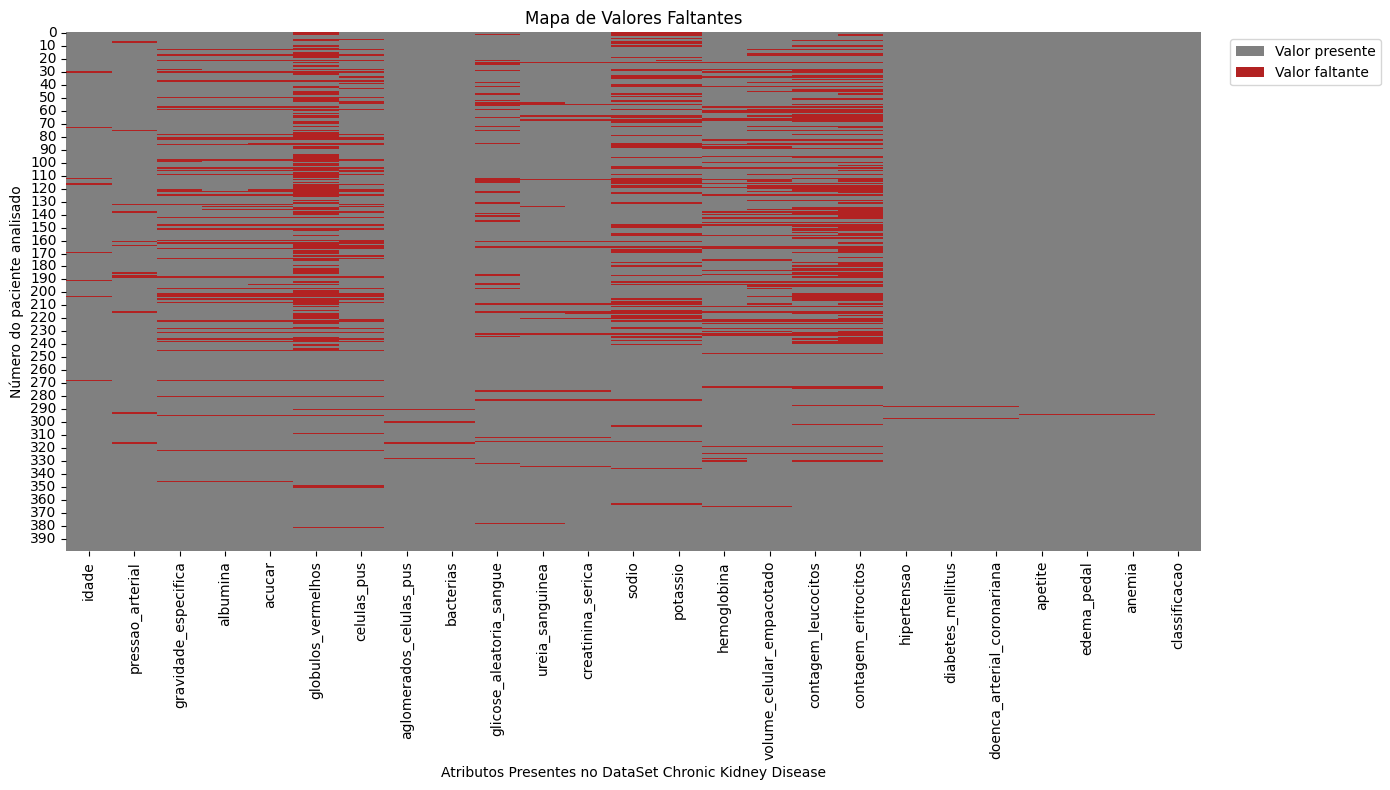

In [10]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=False, cmap=["grey", "firebrick"])
plt.title("Mapa de Valores Faltantes")
plt.xlabel("Atributos Presentes no DataSet Chronic Kidney Disease")
plt.ylabel("Número do paciente analisado")
plt.xticks(rotation=90)

from matplotlib.patches import Patch
legenda = [Patch(facecolor="grey", label="Valor presente"), Patch(facecolor="firebrick", label="Valor faltante")
]
plt.legend(handles=legenda, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [11]:
print(df["classificacao"].unique())

['ckd' 'ckd\t' 'notckd']


<a id="analise"></a>
$ \ \ \ \ \ $ Embora o método `.isnull().sum()` e o heatmap acima provassem que o target `classificacao` não apresenta nenhum valor faltante, o método `.str.strip()` foi implementado para que erros de formatação presentes no DataSet fossem tratados, uma vez que utilizando o método `.unique()`, como vemos acima, o target não apresenta apenas as duas classes relevantes para o problema: "ckd" e "notckd", pois possui "ckd\t" também. 

$ \ \ \ \ \ $ Outra ação importante que podemos fazer para compreender melhor o conjunto de dados analisado é ter uma noção da distribuição dos rótulos das variáveis categóricas binárias, levando em consideração se o paciente em questão possui ou não a doença. Para isos, foram plotados 10 gráficos de barras, um para cada atributo, utilizando a biblioteca `Matplotlib`. Vale ressaltar, que embora o conjunto de dados apresente 13 atributos classificados como categóricos pela documentação original (conforme descrito na [introdução](#intro)), apenas 10 deles são armazenados como texto (object) no DataFrame, sendo os três restantes ("gravidade_especifica", "albumina" e "acucar") representados por códigos numéricos e, por isso, não serão analisados nessa célula com os gráficos de barras.

$ \ \ \ \ \ $ Tendo esclarecido isso, o método `pd.crosstab()` foi utilizado para contabilizar, dentro de cada classe do target (ckd e notckd), quantos pacientes apresentam cada categoria do atributo em questão (por exemplo, quantos pacientes com ckd têm hipertensão e quantos não têm). As barras em vermelho representam a categoria associada à presença de uma condição ou resultado anormal (como "abnormal", "present" ou "yes"), enquanto as barras em azul escuro representam a categoria oposta, permitindo identificar visualmente quais atributos categóricos apresentam distribuições mais distintas entre as duas classes do target.

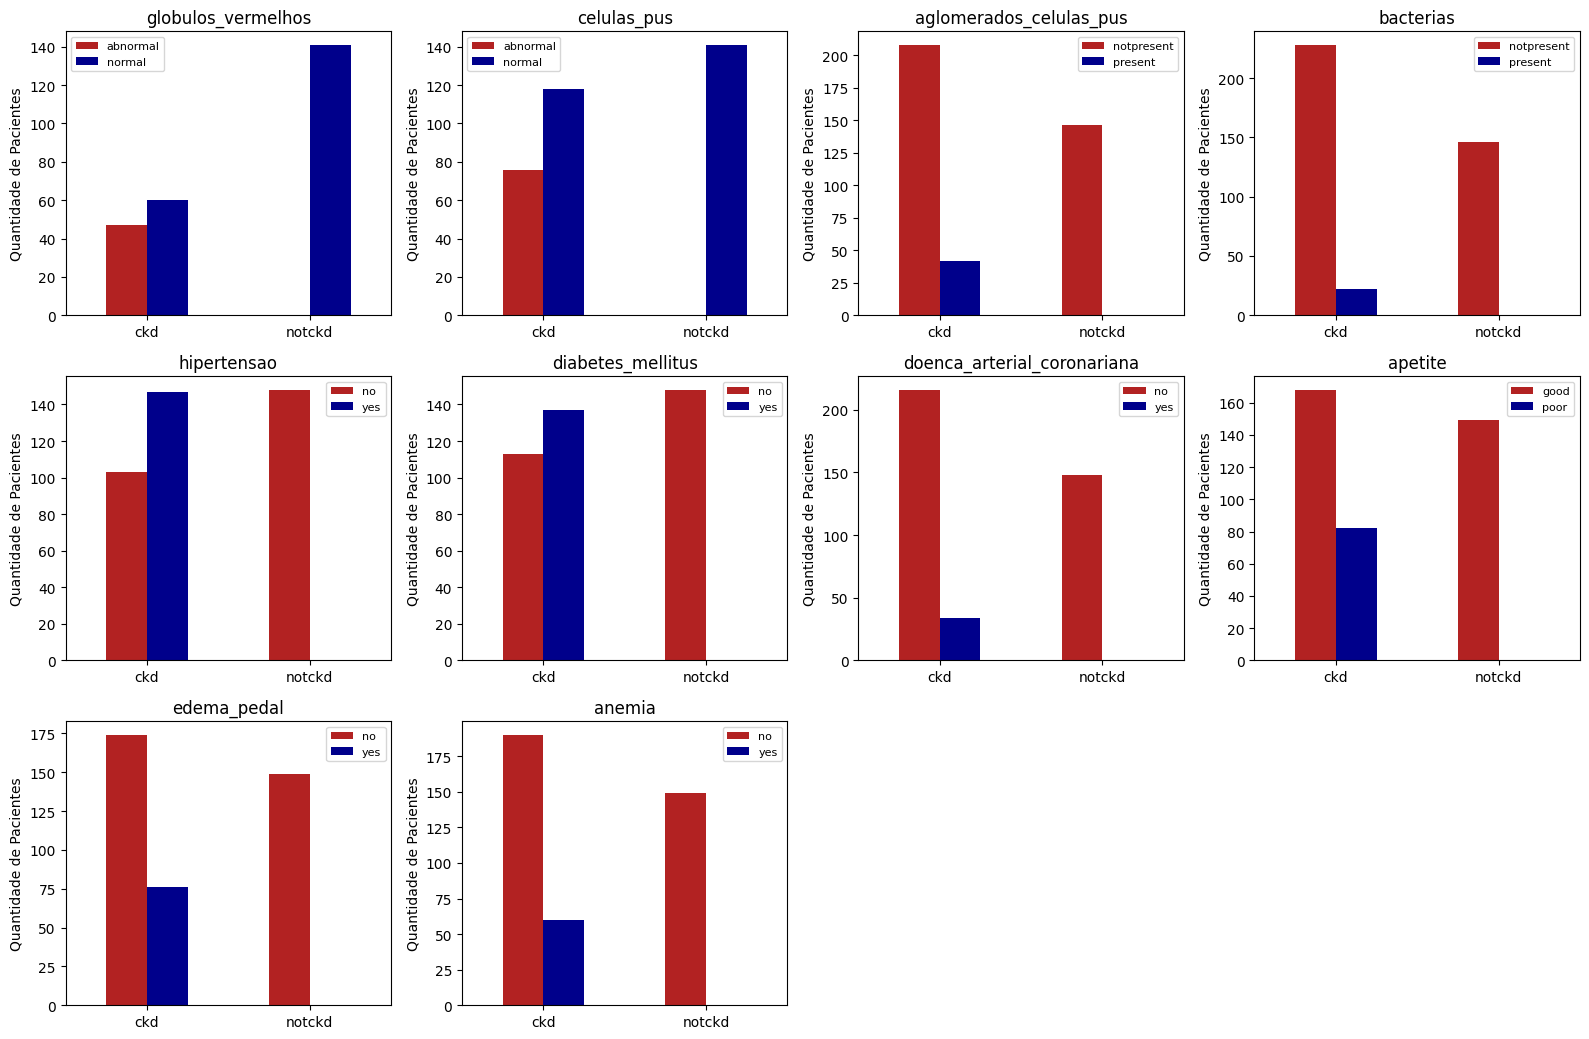

In [12]:
colunas_categoricas = df.select_dtypes(include=["object"]).columns.drop("classificacao") 
for col in colunas_categoricas:
    df[col] = df[col].str.strip() 
    
df["classificacao"] = df["classificacao"].str.strip()

 
colunas_categoricas_dist = df.select_dtypes(include=["object"]).columns.drop("classificacao")
 
n_colunas = 4
n_linhas = -(-len(colunas_categoricas_dist) // n_colunas)
 
fig, eixos = plt.subplots(n_linhas, n_colunas, figsize=(n_colunas*4, n_linhas*3.5))
eixos = eixos.flatten()
 
for i, coluna in enumerate(colunas_categoricas_dist):
    tabela = pd.crosstab(df["classificacao"], df[coluna])
    tabela.plot(kind="bar", ax=eixos[i], color=["firebrick", "darkblue"])
    eixos[i].set_title(coluna)
    eixos[i].set_xlabel("")
    eixos[i].set_ylabel("Quantidade de Pacientes")
    eixos[i].tick_params(axis="x", rotation=0)
    eixos[i].legend(fontsize=8)
 
for j in range(len(colunas_categoricas_dist), len(eixos)):
    fig.delaxes(eixos[j])
 
plt.tight_layout()
plt.show()

$ \ \ \ \ \ $ De forma análoga, para a análise dos atribuos numéricos, foram plotados 14 boxplots, utilizando tanto a biblioteca `seaborn` quanto a `Matplotib`. Cada boxplot foi construído separando os pacientes de acordo com a classe do target, permitindo visualizar, para cada atributo, a mediana, a dispersão e a presença de possíveis valores anômalos, também chamados de outliers, em cada um dos dois grupos. 

$ \ \ \ \ \ $ A representação dos dados dessa forma, busca identificar quais atributos numéricos apresentam distribuições visivelmente distintas entre pacientes com e sem a doença — como é o caso, por exemplo, da hemoglobina e do volume celular empacotado, cujos valores tendem a ser mais baixos em pacientes com DRC, o que é coerente com a anemia frequentemente associada a quadros de insuficiência renal — enquanto outros atributos apresentam maior sobreposição entre as classes, indicando menor capacidade discriminativa individual. Essa análise exploratória, seja através dos gráficos de barras ou por meio dos boxplots, será crucial para fazer a seleção de quais atributos serão utilizados no modelo posteriormente.

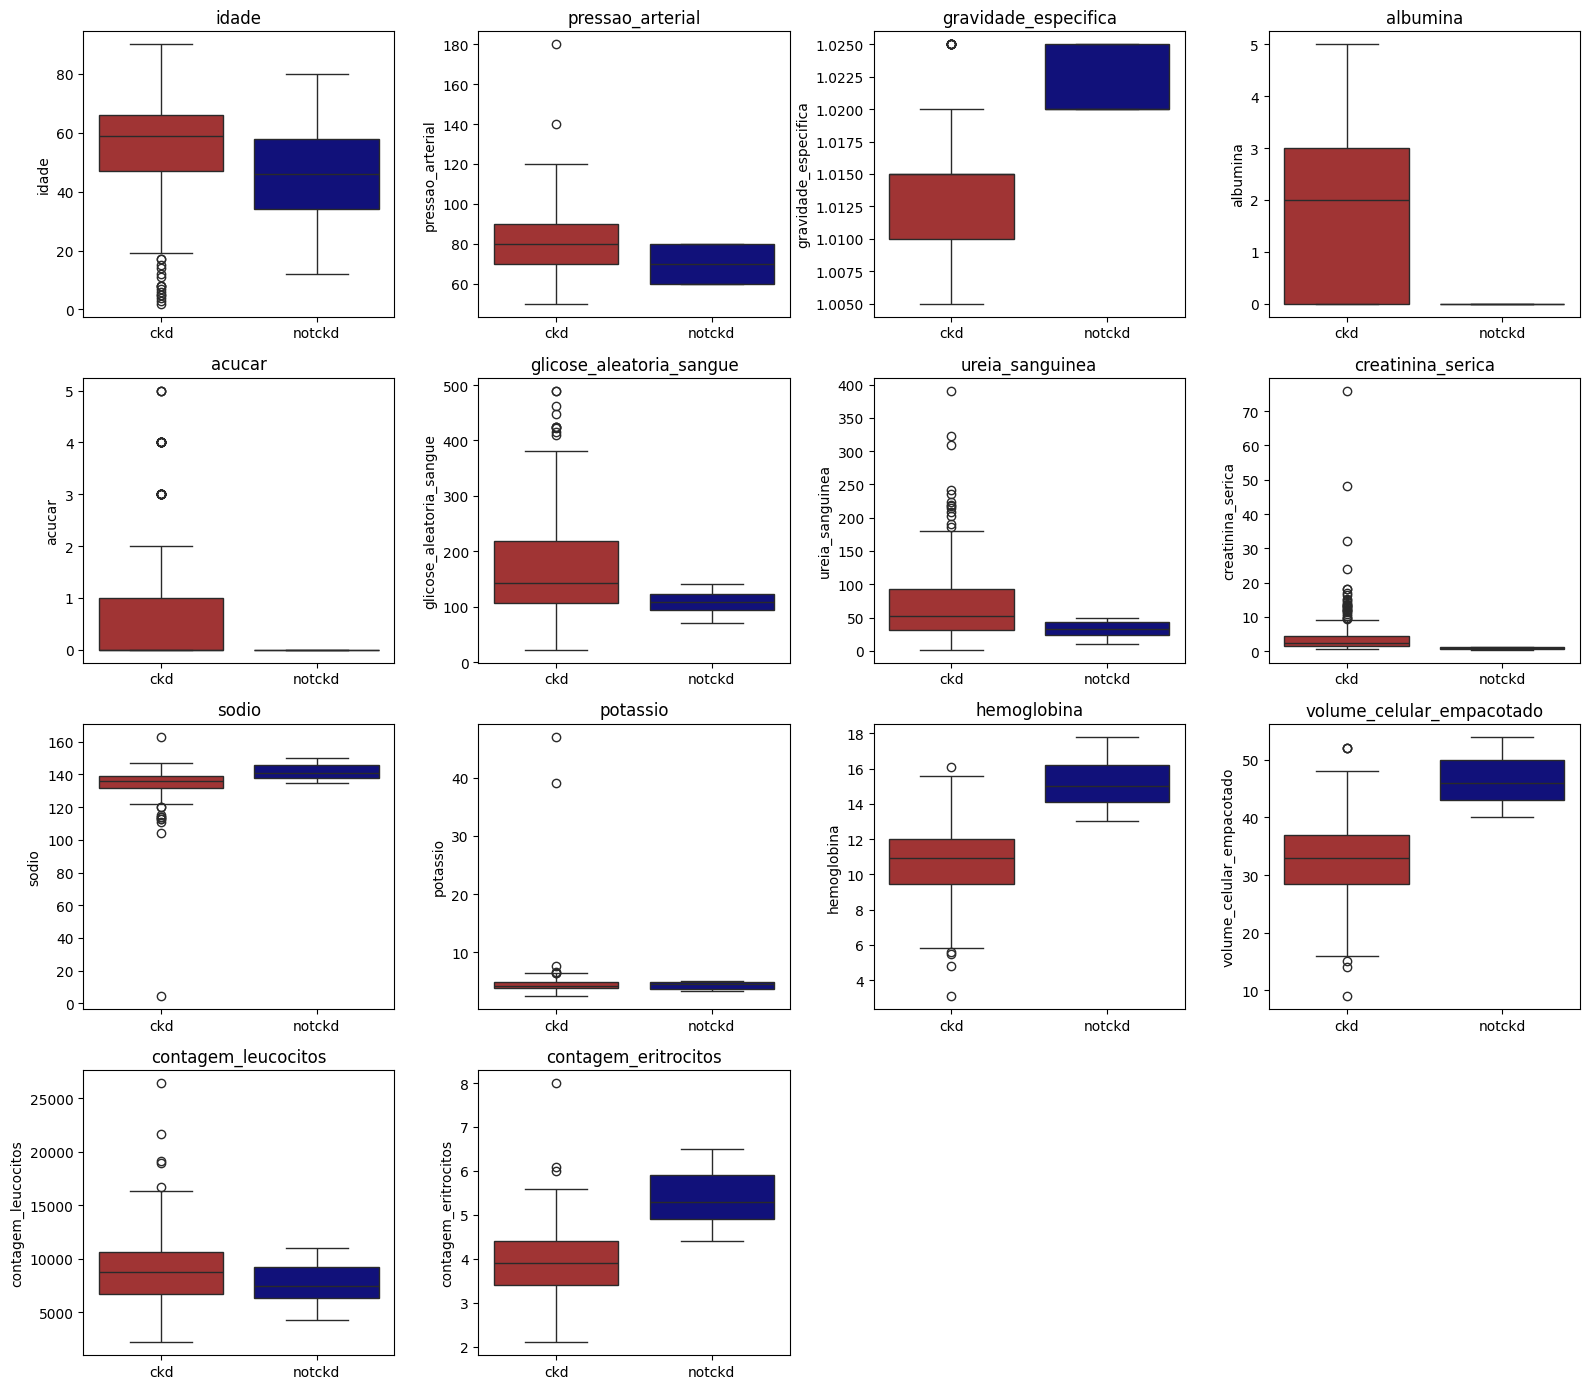

In [13]:
colunas_numericas_plot = df.select_dtypes(include=["float64", "int64"]).columns
 
n_colunas = 4
n_linhas = -(-len(colunas_numericas_plot) // n_colunas) 
 
fig, eixos = plt.subplots(n_linhas, n_colunas, figsize=(n_colunas * 4, n_linhas * 3.5))

eixos = eixos.flatten()
for i, coluna in enumerate(colunas_numericas_plot):
    sns.boxplot(
        data=df, x="classificacao", y=coluna, hue="classificacao", ax=eixos[i],
        palette={"ckd": "firebrick", "notckd": "darkblue"}, legend=False
    )
    eixos[i].set_title(coluna)
    eixos[i].set_xlabel("")
 
for j in range(len(colunas_numericas_plot), len(eixos)):
    fig.delaxes(eixos[j])
 
plt.tight_layout()
plt.show()

$ \ \ \ \ \ $ Com essa análise exploratória tendo sido feita, agora podemos transformar o DataSet para sua utilização. Contudo, com o objetivo de preservar os dados antes das transformações, foi criada uma cópia do DataFrame original utilizando o método `.copy()`. Em seguida, as variáveis categóricas binárias foram então convertidas em variáveis numéricas por meio da implementação do método `.map()`. As categorias "normal", "present", "yes" e "good" foram representadas por 1, enquanto "abnormal", "notpresent", "no" e "poor" foram representadas por 0. 

$ \ \ \ \ \ $ A escolha por essa codificação binária manual, em vez do one-hot encoding, é decorrente do fato de que todas essas variáveis têm só duas categorias. Com apenas duas opções, uma única coluna 0/1 já carrega toda a informação necessária, sem inventar uma ordem entre as categorias que não existe de fato. Assim, a implementação do one-hot encoding aqui criaria, para cada atributo, duas colunas que são espelho uma da outra — se uma é 0, a outra necessariamente é 1 — o que é justamente o problema conhecido como "dummy variable trap" [[8]](#refs): redundância pura, sem informação nova, só aumentando o número de colunas à toa. Isso pesa mais ainda no k-NN, que depende do cálculo de distância entre os pontos e tende a perder desempenho quanto mais atributos são adicionados, o que é chamado de maldição da dimensionalidade [[9]](#refs).

In [14]:
df_copia = df.copy()

df_copia["globulos_vermelhos"] = df_copia["globulos_vermelhos"].map({
    "normal": 1,
    "abnormal": 0
})

df_copia["celulas_pus"] = df_copia["celulas_pus"].map({
    "normal": 1,
    "abnormal": 0
})

df_copia["aglomerados_celulas_pus"] = df_copia["aglomerados_celulas_pus"].map({
    "present": 1,
    "notpresent": 0
})

df_copia["bacterias"] = df_copia["bacterias"].map({
    "present": 1,
    "notpresent": 0
})

df_copia["hipertensao"] = df_copia["hipertensao"].map({
    "yes": 1,
    "no": 0
})

df_copia["diabetes_mellitus"] = df_copia["diabetes_mellitus"].map({
    "yes": 1,
    "no": 0
})

df_copia["doenca_arterial_coronariana"] = df_copia["doenca_arterial_coronariana"].map({
    "yes": 1,
    "no": 0
})

df_copia["apetite"] = df_copia["apetite"].map({
    "good": 1,
    "poor": 0
})

df_copia["edema_pedal"] = df_copia["edema_pedal"].map({
    "yes": 1,
    "no": 0
})

df_copia["anemia"] = df_copia["anemia"].map({
    "yes": 1,
    "no": 0
})

$ \ \ \ \ \ $ Também foi decidido que seriam retiradas quatro das colunas que possuiam mais dados faltantes, para que, ao utilizar o método `dropna()`, não fossem perdidos muitos dados nas linhas restantes. A partir do heatmap e do uso do método `.isnull()`, foi possível observar que os atributos "globulos_vermelhos", "contagem_leucocitos", "potassio" e "sodio" apresentavam consideravelmente mais dados faltantes do que os demais, motivo pelo qual foram removidos do conjunto de dados antes da remoção das linhas incompletas. Optou-se por não retirar o atributo "contagem_eritrocitos", que também estava entre uma das colunas com mais dados faltantes, pois, analisando seu boxplot, seu poder discriminativo é bem alto entre pessoas com ckd e pessoas sem a doença.

In [15]:
colunas_para_remover = ["globulos_vermelhos", "contagem_leucocitos", "potassio", "sodio"]

df_copia = df_copia.drop(columns=colunas_para_remover)
df_copia = df_copia.dropna()

print(df_copia.shape)

(210, 21)


$ \ \ \ \ \ $ Por fim, os rótulos do target `classificacao` foram armazenados, em sua ordem original de aparição (ckd, seguido de notckd), na variável `ordem_labels`, utilizada posteriormente para garantir que a ordem das classes nas matrizes de confusão fosse sempre consistente ao longo do trabalho, por meio do método `.unique()`.

In [16]:
ordem_labels = df["classificacao"].unique().tolist()
ordem_labels

['ckd', 'notckd']

$ \ \ \ \ \ $  Do total de 400 casos utilizados no estudo, 250 foram classificados como portadores de Doença Renal Crônica (ckd) e os 150 restantes como não portadores da doença (notckd). Contudo, após a limpeza de dados essa proporção muda e influencia a análise de modelos. Com o objetivo de compreender se as classes do target ainda estavam desbalanceadas, mesmo após a limpeza, foi plotado um gráfico que representa a distribuição dos rótulos do target utilizando a biblioteca `Matplotlib`.  

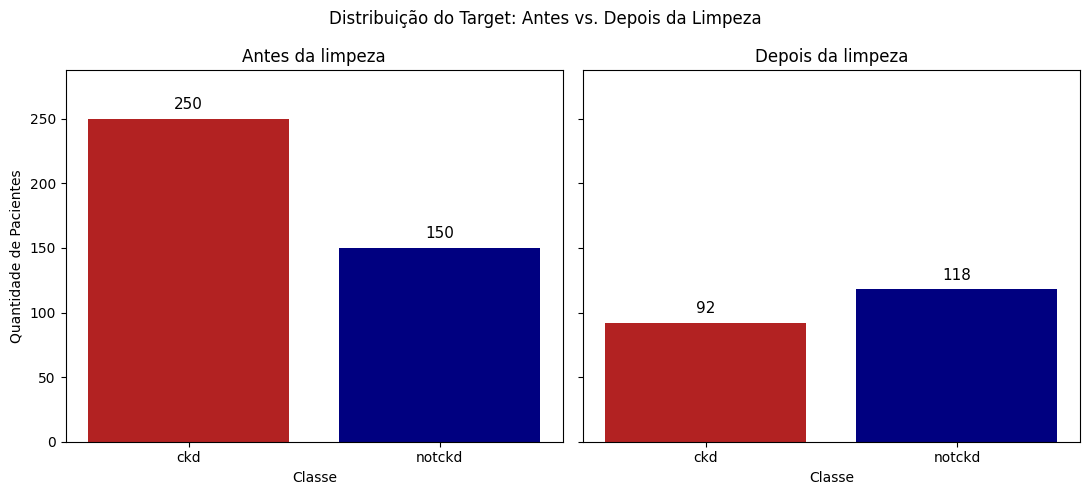

In [39]:
ordem_fixa = ["ckd", "notckd"]

contagem_antes = df["classificacao"].value_counts().reindex(ordem_fixa)
contagem_depois = df_copia["classificacao"].value_counts().reindex(ordem_fixa)

cores = {"ckd": "firebrick", "notckd": "navy"}
rotulos_legiveis = {"ckd": "ckd", "notckd": "notckd"}

fig, eixos = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

maior_valor = max(contagem_antes.max(), contagem_depois.max())

for eixo, contagem, titulo in zip(eixos, [contagem_antes, contagem_depois], ["Antes da limpeza", "Depois da limpeza"]):
    eixo.bar(
        contagem.index,
        contagem.values,
        color=[cores[classe] for classe in contagem.index]
    )
    eixo.set_xticks(range(len(contagem.index)))
    eixo.set_xticklabels([rotulos_legiveis[classe] for classe in contagem.index])
    eixo.set_xlabel("Classe")
    eixo.set_title(titulo)
    eixo.set_ylim(0, maior_valor * 1.15)

    for i, valor in enumerate(contagem.values):
        eixo.text(i, valor + maior_valor * 0.02, str(valor), ha="center", va="bottom", fontsize=11)

eixos[0].set_ylabel("Quantidade de Pacientes")
fig.suptitle("Distribuição do Target: Antes vs. Depois da Limpeza")

plt.tight_layout()
plt.show()

$ \ \ \ \ \ $ A partir da análise do gráfico, observou-se que, mesmo após a limpeza, por mais que menor, o DataSet ainda apresenta um certo desbalanceamento entre as classes, com a categoria **notckd** sendo, agora, a mais frequente. Esse desbalanceamento é relevante para a interpretação dos resultados do modelo, uma vez que métricas como a acurácia podem ser enganosas em conjuntos de dados desbalanceados. Além disso, um modelo que sempre prevê a classe majoritária, como o baseline, tende a apresentar uma acurácia alta mesmo sem aprender nenhum padrão real.

<a id="sep"></a>
### 3.2 Separação dos Dados de Treino e Teste

$ \ \ \ \ \ $ Uma etapa fundamental que deve ser feita antes do desenvolvimento de qualquer modelo de Aprendizado de Máquina é a Estratégia de Holdout, também chamada de divisão em treino e teste, no inglês: train-test split. Essa técnica consiste em separar o conjunto de dados em duas partes: uma destinada ao treinamento do modelo e outra reservada para sua avaliação. 

$ \ \ \ \ \ $ Os dados de treinamento correspondem às observações utilizadas pelo algoritmo durante o processo de aprendizagem, permitindo o ajuste de seus parâmetros internos. Já os dados de teste permanecem ocultos durante o treinamento e são utilizados posteriormente para avaliar a capacidade de generalização do modelo, isto é, sua habilidade de realizar previsões corretas para dados que não foram vistos anteriormente, sem que haja sobreajuste.

$ \ \ \ \ \ $ Para a implementação do código, deve-se importar a função `train_test_split` do módulo `scikit-learn` e definir quanto dos dados vamos reservar para o conjunto de teste. Nesse caso, 20% dos dados serão reservados para o teste, enquanto que os 80% restantes serão utilizados para o treino. A divisão foi realizada de forma estratificada, por meio do argumento `stratify`, aplicado sobre a coluna `classificacao`, garantindo que a proporção entre as classes do target sejam preservadas tanto no conjunto de treino quanto no de teste, evitando que a divisão aleatória resulte, por acaso, em subconjuntos com proporções de classes muito diferentes entre si, uma vez que vivos no Pré-Processamento de Dados que, mesmo após a limpeza, o target continua desbalanceado.

$ \ \ \ \ \ $ Além disso, vale ressaltar que foi definida uma semente aleatória que mantém a reprodutibilidade dos resultados obtidos, passando o seu valor para o argumento `random_state`, garantindo que o conjunto de treino e teste será sempre o mesmo. A implementação do código seguiu o material didático não publicado do Prof. Dr. Daniel Roberto Cassar "Divisão de dados em treino e teste" [[10]](#refs)

In [18]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.2
SEMENTE_ALEATORIA = 110
TARGET = "classificacao"

indices = df_copia.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA,  stratify=df_copia[TARGET]
)

df_treino = df_copia.loc[indices_treino]
df_teste = df_copia.loc[indices_teste]

print(df_treino.shape, df_teste.shape)

(168, 21) (42, 21)


<a id="escolha"></a>
### 3.3 Escolha e Treino de um Modelo Preditivo

$ \ \ \ \ \ $ A seleção dos atributos utilizados no modelo foi realizada com base na [análise exploratória](#analise) apresentada anteriormente, em particular nos boxplots dos atributos numéricos e nos gráficos de barras dos atributos categóricos, ambos segmentados por classe do target. Foram priorizados os atributos que apresentaram maior diferença visual entre pacientes com (ckd) e sem (notckd) Doença Renal Crônica, sob a premissa de que uma separação mais evidente entre as distribuições das classes indica maior potencial discriminativo para o modelo k-NN, cujo funcionamento depende diretamente da proximidade entre pacientes com características semelhantes. Assim, as variáveis escolhidas foram: "gravidade_especifica", "albumina","hemoglobina", "creatinina_serica", "hipertensao", "glicose_aleatoria_sangue", "apetite".

In [31]:
ATRIBUTOS = ["gravidade_especifica","albumina","hemoglobina","creatinina_serica","hipertensao", "glicose_aleatoria_sangue", "apetite", "contagem_eritrocitos" ]

X_treino = df_treino[ATRIBUTOS].values
X_teste = df_teste[ATRIBUTOS].values
y_treino = df_treino[TARGET].values
y_teste = df_teste[TARGET].values

$ \ \ \ \ \ $ O algoritmo k-NN classifica uma nova observação com base na distância entre ela e seus vizinhos mais próximos no conjunto de treino, geralmente calculada pela distância euclidiana. Esse cálculo é sensível à escala dos atributos. Variáveis que assumem valores numericamente maiores tendem a dominar a distância, mesmo que não sejam as mais relevantes para a separação entre as classes, enquanto variáveis de escala pequena acabam tendo pouca influência no resultado, independentemente do seu real poder discriminativo. No conjunto de atributos utilizado, por exemplo, "glicose_aleatoria_sangue" assume valores na casa das centenas, enquanto "gravidade_especifica" varia numa faixa muito estreita, entre 1.005 e 1.025 - sem normalização, a diferença entre pacientes na glicose pesaria muito mais no cálculo da distância do que a diferença na gravidade específica, distorcendo a importância relativa de cada atributo.

$ \ \ \ \ \ $ Para corrigir essa distorção, aplicou-se o `StandardScaler`, que padroniza cada atributo subtraindo sua média e dividindo pelo seu desvio padrão, de forma que todas as variáveis passem a ter média 0 e desvio padrão 1. Com isso, cada atributo contribui para o cálculo da distância de acordo com sua real capacidade de separar as classes, e não de acordo com a unidade ou a escala em que foi originalmente medido.

$ \ \ \ \ \ $ É importante destacar que o StandardScaler foi ajustado apenas com os dados de treino, e essa mesma transformação foi aplicada tanto ao treino quanto ao teste, objetivando evitar o vazamento de dados, também chamado de data leakage. Se a média e o desvio padrão fossem calculados sobre o conjunto de dados completo, informações do conjunto de teste estariam implicitamente influenciando o pré-processamento do treino, o que comprometeria a avaliação da capacidade de generalização do modelo para dados nunca vistos.

In [32]:
from sklearn.preprocessing import StandardScaler

normalizador = StandardScaler()
normalizador.fit(X_treino)

X_treino = normalizador.transform(X_treino)
X_teste = normalizador.transform(X_teste)

<a id="base"></a>
### 3.4 Modelo de Classificação: Baseline

$ \ \ \ \ \ $ O Modelo Baseline, também chamado de dummy, linha de base ou modelo fictício, é um modelo muito simples que é utilizado para comparar o desempenho de modelos mais complexos. Empregando a estratégia da classe majoritária, o classificador realiza suas previsões atribuindo sempre a categoria mais frequente observada no conjunto de treinamento, ou seja, a moda do target. Para implementá-lo, seguiu-se orientação fornecida no material do Prof. Dr. Daniel Roberto Cassar "Modelo linear e baseline" [[11]](#refs) em que é necessário importar a classe `DummyClassifier`, fazer uma instância e, em seguida, um ajuste `.fit()`.

In [33]:
from sklearn.dummy import DummyClassifier

modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino, y_treino) 

,strategy,'prior'
,random_state,None
,constant,None


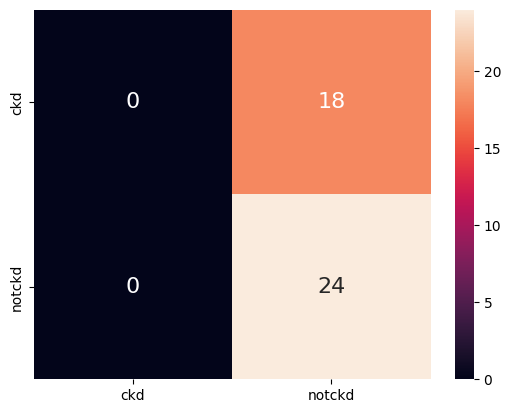

In [34]:
from sklearn.metrics import confusion_matrix

y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

In [35]:
from sklearn.metrics import accuracy_score
acuracia_baseline = accuracy_score(y_verdadeiro, y_previsao)
print(f"Acurácia do Modelo Baseline: {(acuracia_baseline*100):.2f}%")

Acurácia do Modelo Baseline: 57.14%


$ \ \ \ \ \ $ Uma acurácia de 57,14% reflete a distribuição dos rótulos do target, uma vez que o `DummyClassifier`prevê sempre a classe majoritária observada no conjunto de treinamento. Entretanto, percebe-se uma pequena divergência entre esse valor e a proporção geral das classes no conjunto de dados completo. Essa diferença decorre da aleatoriedade inerente ao processo de divisão dos dados: embora o parâmetro stratify busque preservar a proporção original das classes tanto no conjunto de treino quanto no de teste, essa preservação é apenas aproximada, já que o número de pacientes em cada subconjunto é finito e não permite uma divisão exatamente proporcional. Além disso, a divisão específica obtida depende da semente aleatória (random_state) utilizada, de modo que diferentes valores de semente resultariam em subconjuntos de treino e teste distintos, e, consequentemente, em pequenas variações na acurácia do modelo baseline.

<a id="knn"></a>
### 3.5 Modelo de Classificação: k-vizinhos mais próximos

$ \ \ \ \ \ $ O algoritmo de k-vizinhos mais próximos é um algoritmo supervisionado de classificação (ou seja, ele recebe atributos, também chamados de features, e retorna a previsão de um ou mais targets categóricos, por se tratar de um modelo de classificação) baseado na proximidade entre exemplos, em que a classe de uma observação é determinada a partir das classes de seus vizinhos mais próximos, como já mencionado na sessão Escolha e Treino de um Modelo Preditivo. 

$ \ \ \ \ \ $ Esse algoritmo foi escolhido para o problema em questão, pois espera-se que as medições fisiológicas sejam comparáveis entre indivíduos em situações físicas similares. Por exemplo, pessoas saudáveis devem apresentar medições fisiológicas consistentes dentro de uma determinada faixa. Ao comparar indivíduos com alguma doença, as medições de um indivíduo doente devem ser comparáveis às de uma pessoa com um grau similar da mesma condição. Assim, não devem existir discrepâncias significativas nos dados coletados a partir de medições fisiológicas entre indivíduos com circunstâncias comparáveis. 

$ \ \ \ \ \ $ Para implementarmos o algoritmo, foi seguido o passo à passo fornecido no material didático não publicado do Prof. Dr. Daniel Roberto Cassar "Aprendizado de máquina, k-NN e métricas" [[12]](#refs). Para sua implementação é necessário instanciar um modelo, que consiste em determinar os parâmetros de interesse e armazená-los em um objeto de fácil acesso. Com isso, ajustamos o modelo aos dados, por meio do método `.fit()`, e só depois podemos realizar uma previsão, através do método `.predict()`.

In [36]:
from sklearn.neighbors import KNeighborsClassifier
NUM_VIZINHOS = 3

modelo_knn = KNeighborsClassifier(NUM_VIZINHOS)
modelo_knn.fit(X_treino, y_treino)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


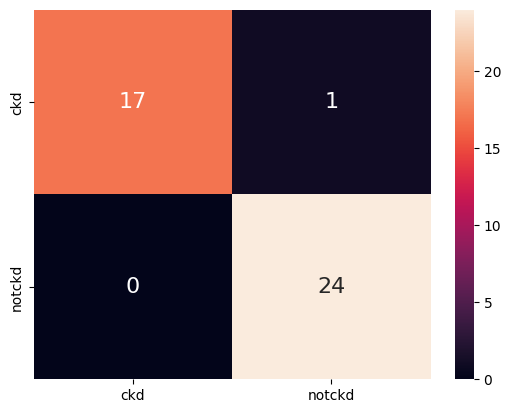

In [37]:
y_verdadeiro_knn = y_teste
y_previsao_knn = modelo_knn.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro_knn, y_previsao_knn, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

<a id="met"></a>
### 3.6 Métricas de Desempenho

$ \ \ \ \ \ $ Com base nos valores obtidos na matriz de confusão, cuja estrutura base está representada abaixo, é possível definir diversas métricas de desempenho para problemas de classificação, como a Acurácia, o Recall, a Precisão e o F1-Score. Métricas reportam o desempenho de modelos em um valor numérico, refletindo como seu modelo se comporta ao tentar prever dados que a resposta já é conhecida.

| |Valor predito = 1|Valor predito = 0|
|---|---|---|
| <b>Valor real = 1</b>|VP|FN|
| <b>Valor real = 0</b>|FP|VN|



**Acurácia** = (VP + VN) / total. Mede a proporção geral de acertos, sem distinguir o tipo de erro. É intuitiva, mas em datasets desbalanceados, pode mascarar um desempenho ruim na classe minoritária, uma vez que um modelo que sempre chuta a classe majoritária (como o baseline) já tem acurácia relativamente alta sem aprender nada de útil.

$ \ \ \ \ \ $ **Recall (sensibilidade)** = VP / (VP + FN). Responde a questão: "de todos os pacientes que realmente têm a doença, quantos o modelo conseguiu identificar?". Foca no custo de falsos negativos, que seriam o caso mais grave em que o modelo deixa de detectar quem está doente.

$ \ \ \ \ \ $ **Precisão** = VP / (VP + FP). Responde a seguinte questão: "de todos os pacientes que o modelo classificou como doentes, quantos realmente estavam?". Foca no custo de falsos positivos, no caso de alarmar alguém saudável.

$ \ \ \ \ \ $ **F1-score** = média harmônica entre precisão e recall. É útil quando você quer um equilíbrio entre as duas, especialmente em cenários desbalanceados onde nem acurácia nem uma métrica isolada contam a história toda por trás do modelo.

In [38]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acuracia = accuracy_score(y_verdadeiro_knn, y_previsao_knn)
recall = recall_score(y_verdadeiro_knn, y_previsao_knn, pos_label='ckd')
precisao = precision_score(y_verdadeiro_knn, y_previsao_knn, pos_label='ckd')
f1 = f1_score(y_verdadeiro_knn, y_previsao_knn, pos_label='ckd')

print(f"Acurácia do modelo: {(acuracia*100):.2f}%")
print(f"Recall: {(recall*100):.2f}%")
print(f"Precisão: {(precisao*100):.2f}%")
print(f"F1: {(f1*100):.2f}%")

Acurácia do modelo: 97.62%
Recall: 94.44%
Precisão: 100.00%
F1: 97.14%


$ \ \ \ \ \ $ A acurácia do k-NN ficou 40,48 pontos percentuais acima da do baseline, o que reflete o fato de que o baseline chuta sempre a mesma classe, sem olhar nenhum atributo do paciente e aprender nenhum padrão, enquanto o k-NN usa a distância entre os atributos clínicos para decidir. Como vimos nos boxplots, vários desses atributos têm distribuições bem diferentes entre quem tem e quem não tem a doença.

$ \ \ \ \ \ $ O recall para a classe ckd foi de 94,44%: o modelo identificou corretamente a grande maioria dos pacientes doentes, deixando passar cerca de 5,56% como falsos negativos, o que caracteriza-se como um bom resultado, já que minimizar esse tipo de erro é a prioridade num contexto de diagnóstico médico, embora mesmo essa pequena fração represente um risco real.

$ \ \ \ \ \ $ A precisão foi de 100% — nenhum paciente saudável foi classificado como doente. Ou seja, todo erro do modelo foi para o lado do falso negativo, não do falso positivo, o padrão inverso do que normalmente se prefere em diagnóstico médico (onde errar por excesso de cautela costuma ser menos grave). É justamente esse tipo de erro que mereceria atenção numa aplicação clínica real.

$ \ \ \ \ \ $ Por fim, O F1-score, que resume essas duas métricas, ficou em 97,14%, refletindo o forte desempenho geral do modelo.

<a id="hiper"></a>
### 3.7 Variando os Hiperparâmetros

$ \ \ \ \ \ $ Todos os parâmetros de modelos de aprendizado de máquina que devem ser definidos antes do processo de treino são chamados de **hiperparâmetros**. No modelo $k$-NN, o número de vizinhos definido no momento que o modelo é instanciado passa a ser um valor fixo daquela instância particular do modelo, esse valor não se altera durante o processo de treino do modelo. Logo, o número de vizinhos do algoritmo $k$-NN é um hiperparâmetro. A distância utilizada para prever o rótulo do target também é um hiperparâmetro, podendo ser a distância euclidiana, a distância de Manhattan ou a distância de Chebyshev. 

$ \ \ \ \ \ $ A distância euclidiana, calculada por $d = \sqrt{\sum(x_i - y_i)^2}$, corresponde à distância em linha reta entre dois pontos, sendo a mais intuitiva geometricamente e a mais sensível a grandes diferenças em uma única dimensão, pois os termos são elevados ao quadrado. A distância de Manhattan, $d = \sum|x_i - y_i|$, soma as diferenças absolutas entre as coordenadas, como se o deslocamento entre dois pontos só pudesse ocorrer ao longo dos eixos. Por não elevar as diferenças ao quadrado, é menos sensível a outliers. Já a distância de Chebyshev, $d = \max_i|x_i - y_i|$, considera apenas a maior diferença entre as coordenadas dos dois pontos, ignorando as demais dimensões, sendo equivalente ao número mínimo de movimentos de um rei no tabuleiro de xadrez para ir de um ponto a outro.

$ \ \ \ \ \ $ Além disso, o tipo de normalização utilizada também pode ser considerado um hiperparâmetro. Normalização é o processo de transformar os dados para uma certa escala em comum. Existem três tipos usuais de normalizações lineares (em que a distribuição dos dados não é alterada) para dados numéricos: normalização padrão, normalização pelo máximo absoluto e normalização pelo mínimo e máximo. A normalização padrão (StandardScaler) - utilizada anteriormente -, $x' = \dfrac{x - \mu}{\sigma}$, transforma os dados para que apresentem média 0 e desvio-padrão 1, com base na média ($\mu$) e no desvio-padrão ($\sigma$) da distribuição original. A normalização pelo mínimo e máximo (MinMaxScaler), $x' = \dfrac{x - x_{min}}{x_{max} - x_{min}}$, reescala os dados para o intervalo fixo entre 0 e 1, com base nos valores mínimo e máximo observados. Já a normalização pelo máximo absoluto (MaxAbsScaler), $x' = \dfrac{x}{\max(|x|)}$, divide cada valor pelo maior valor absoluto da distribuição, resultando em dados no intervalo entre -1 e 1, sem deslocar a posição do zero original, e sendo, portanto, um tipo de normalização em que a esparsividade não é perdida.

$ \ \ \ \ \ $ Encontrar o conjunto de hiperparâmetros que induz o melhor modelo preditivo é um problema NP-difícil, e que é necessário testar todos os possíveis conjuntos de hiperparâmetros para ter certeza que encontrou o seu melhor conjunto.

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=140)

X_treino_cv = df_treino[ATRIBUTOS].values
y_treino_cv = df_treino[TARGET].values

normalizadores = {
    "Nenhum": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
}
distancias = ["euclidean", "manhattan", "chebyshev"]
valores_de_k = range(1, 16)

resultados = []
for nome_norm, normalizador in normalizadores.items():
    for dist in distancias:
        for k in valores_de_k:
            etapas = []
            if normalizador is not None:
                etapas.append(("scaler", normalizador))
            etapas.append(("knn", KNeighborsClassifier(n_neighbors=k, metric=dist)))
            modelo = Pipeline(etapas)

            scores = cross_val_score(modelo, X_treino_cv, y_treino_cv, cv=cv, scoring="accuracy")
            resultados.append({"normalizacao": nome_norm, "distancia": dist, "k": k,
                                "acuracia_media": scores.mean(), "desvio_padrao": scores.std()})

df_resultados = pd.DataFrame(resultados)

$ \ \ \ \ \ $ Para visualizar o impacto conjunto dos três hiperparâmetros analisados, foi construída uma figura com três painéis lado a lado, um para cada função de distância, utilizando o método `plt.subplots()` da biblioteca `Matplotlib`. Dentro de cada painel, foram traçadas quatro curvas, correspondentes às quatro formas de normalização testadas, mostrando a acurácia média obtida por validação cruzada em função do número de vizinhos (k), que varia de 1 a 15.

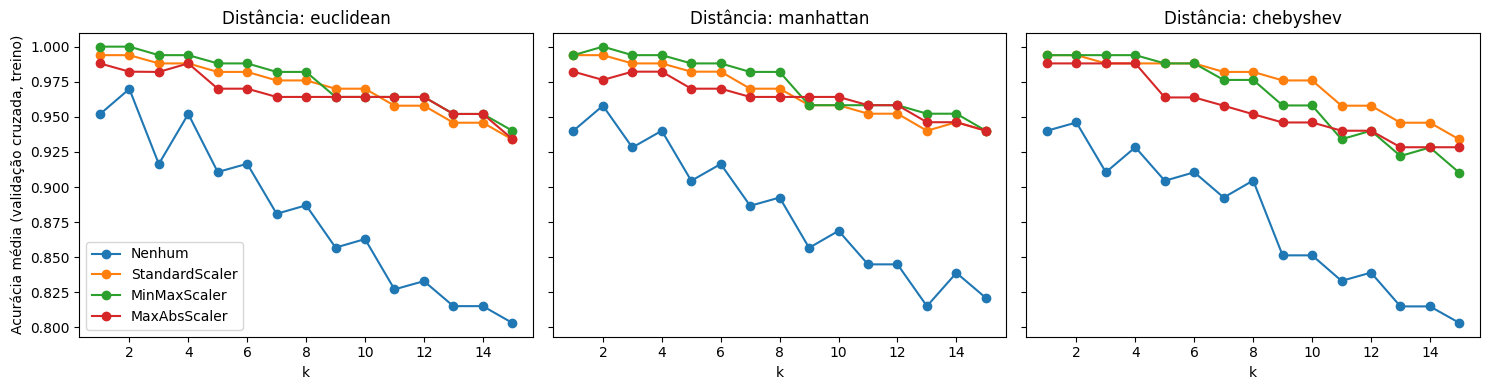

In [28]:
fig, eixos = plt.subplots(1, len(distancias), figsize=(15, 4), sharey=True)

for eixo, dist in zip(eixos, distancias):
    subset = df_resultados[df_resultados["distancia"] == dist]
    for nome_norm in normalizadores:
        dados = subset[subset["normalizacao"] == nome_norm]
        eixo.plot(dados["k"], dados["acuracia_media"], marker="o", label=nome_norm)
    eixo.set_title(f"Distância: {dist}")
    eixo.set_xlabel("k")

eixos[0].set_ylabel("Acurácia média (validação cruzada, treino)")
eixos[0].legend()
plt.tight_layout()
plt.show()

$ \ \ \ \ \ $ Buscamos plotar uma representação, em formato de heatmap, que resume a melhor acurácia média obtida para cada combinação de normalização e distância, considerando todos os valores de k testados:

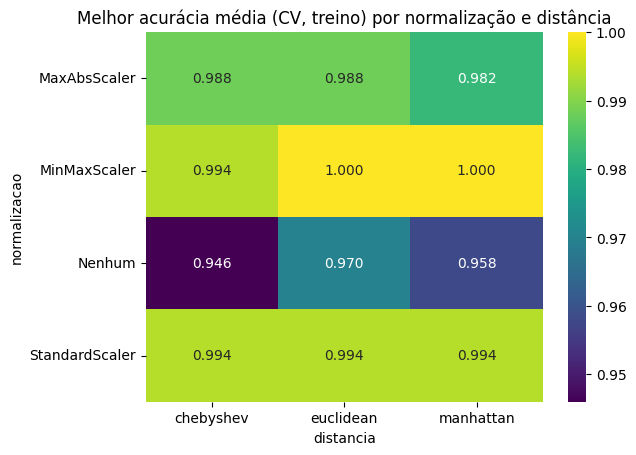

In [29]:
resumo = df_resultados.groupby(["normalizacao", "distancia"])["acuracia_media"].max().unstack()
sns.heatmap(resumo, annot=True, fmt=".3f", cmap="viridis")
plt.title("Melhor acurácia média (CV, treino) por normalização e distância")
plt.show()

$ \ \ \ \ \ $ A partir da análise da figura que contém 3 gráficos, observa-se um padrão consistente nos três painéis: a acurácia média decresce à medida que o valor de k aumenta, independentemente da distância ou da normalização utilizada. Além disso, a diferença de desempenho entre os dados normalizados e os dados brutos (curva "Nenhum") também é bem evidente. Enquanto as três formas de normalização mantêm acurácias relativamente altas e estáveis, acima de 0,93 mesmo para k=15, o modelo sem normalização possii sua acurácia diminuída de forma acentuada, chegando a valores próximos de 0,80.

$ \ \ \ \ \ $ Com relação ao heatmap, duas combinações (MinMaxScaler com distância euclidiana e MinMaxScaler com distância de Manhattan) atingiram acurácia média de 100% na validação cruzada - resultado que, embora possa parecer, à primeira vista, um indício de excelente desempenho, é, na verdade, um resultado que exige cautela antes de ser aceito. Assim como visto no painel, o pico de acurácia em cada curva ocorre justamente nos valores mais baixos de k. K=1 é conhecido por ser o cenário mais propenso a superajuste, já que a classificação de cada ponto depende de um único vizinho, tornando o modelo extremamente sensível a padrões específicos do conjunto de treino, sem garantir de que esse desempenho se mantenha em dados nunca vistos antes pelo modelo. 

$ \ \ \ \ \ $ Dessa forma, o valor de 100% provavelmente não representa a configuração de hiperparâmetros mais indicada para generalização, sendo mais indicado considerar, na escolha do modelo final, valores de k um pouco mais altos, que sacrifiquem uma pequena fração da acurácia média, para se ter uma maior estabilidade e um menor risco de  sobreajuste, ainda mais quando utiliza-se um DataSet pequeno.

$ \ \ \ \ \ $ Por fim, para quantificar de forma explícita a amplitude da busca de hiperparâmetros realizada, calculou-se o número total de combinações testadas: 

In [30]:
n_normalizacoes = len(normalizadores)
n_distancias = len(distancias)
n_valores_k = len(valores_de_k)

total_combinacoes = n_normalizacoes * n_distancias * n_valores_k

print(f"Normalizações testadas: {n_normalizacoes}")
print(f"Distâncias testadas: {n_distancias}")
print(f"Valores de k testados: {n_valores_k}")
print(f"Total de conjuntos de hiperparâmetros testados: {total_combinacoes}")
print(f"Linhas em df_resultados: {len(df_resultados)}")

Normalizações testadas: 4
Distâncias testadas: 3
Valores de k testados: 15
Total de conjuntos de hiperparâmetros testados: 180
Linhas em df_resultados: 180


<a id="conclusao"></a>
## 4. Conclusões e Principais Aprendizados

$ \ \ \ \ \ $ Portanto, esse trabalho colocou em prática diversos conceitos ensinados na disciplina de Aprendizado de Máquina, a partir da indução de um modelo supervisionado de classificação capaz de prever, com base em dados clínicos reais, se um paciente é portador de Doença Renal Crônica. Foram abordadas etapas cruciais do pré-processamento de dados, desde a importação do conjunto de dados até estratégias de limpeza e análise exploratória, em especial no quesito gráfico, além da implementação de algoritmos como o baseline e o k-NN, e da variação sistemática de seus hiperparâmetros, incluindo diferentes formas de normalização linear e diferentes funções de distância. Também foram discutidas métricas de desempenho para problemas de classificação além daquelas vistas previamente em sala de aula.

$ \ \ \ \ \ $ Os resultados obtidos mostram que o k-NN superou consideravelmente o modelo baseline (de acordo com a métrica de desempenho acurácia), evidenciando que os atributos clínicos selecionados carregam informação real sobre a presença da doença. Vale destacar também que, apesar de seu bom desempenho preditivo, o k-NN apresenta limitações quanto à interpretabilidade. Diferentemente de modelos como a regressão logística, que atribuem um coeficiente numérico a cada atributo, permitindo quantificar exatamente o quanto cada variável contribui para a previsão, o k-NN não oferece esse tipo de explicação agregada: a relevância de cada atributo está implícita no cálculo de distância, sem ser explicitada em um número interpretável. Além disso, essa interpretabilidade tende a se deteriorar à medida que o número de atributos aumenta — com os 8 a 9 atributos utilizados neste trabalho, ainda é possível visualizar e raciocinar sobre a proximidade entre pacientes de forma razoavelmente intuitiva, mas esse tipo de raciocínio deixa de fazer sentido em espaços de dimensionalidade muito mais alta. Por fim, o desempenho final do modelo depende fortemente da escolha dos hiperparâmetros, de um jeito que não fica evidente ao se observar apenas o resultado: sem conhecer todo o processo de busca realizado, um único valor de acurácia não revela o quanto esse resultado dependeu das escolhas de k, distância e normalização.

$ \ \ \ \ \ $ Diante do exposto, conclui-se que o modelo induzido apresenta potencial de aplicação, mas que sua confiabilidade seria fortalecida por um conjunto de dados maior — visto que o conjunto de teste utilizado contou com apenas 42 pacientes, tornando as métricas obtidas sensíveis a variações relativamente pequenas no número de acertos e erros. Caso esse trabalho fosse expandido futuramente, e aprimorado no decorrer das aulas da disciplina, aumentando a fundamentação teórica, sugere-se explorar outras formas de seleção de atributos mais discriminativos para o modelo, comparar o desempenho do k-NN com algoritmos mais interpretáveis, como a regressão logística ou árvores de decisão, e avaliar a robustez dos resultados em uma amostra maior e mais diversa de pacientes, talvez com dados de pacientes aqui do Brasil, que provavelmente diferem dos da população indiana.

<a id="interacao"></a>
## 5. Descrição do uso de IA neste trabalho

$ \ \ \ \ \ $ Ao longo do desenvolvimento deste trabalho, foi utilizada a ferramenta de Inteligência Artificial Claude [[13]](#refs) como apoio em diferentes etapas do processo, como na depuração de código (debug), em que a IA foi utilizada para identificar a causa de diversos erros e avisos (warnings) encontrados durante a execução do notebook. Entre os principais casos, que fui sempre anotando, podemos citar:  um ValueError de valores NaN no KNeighborsClassifier, causado por uma célula que reintroduzia dados faltantes ao ser executada fora de ordem; um KeyError decorrente da tentativa de remover colunas já removidas em uma execução anterior da mesma célula; um DataConversionWarning gerado pelo formato incorreto do vetor de rótulos (y), resolvido com o uso do método .ravel(); e um problema no método rename(), no qual algumas colunas não eram renomeadas corretamente - utilizou-se a IA para investigar a causa, que se revelou uma divergência entre os nomes de coluna documentados no site do UCI Machine Learning Repository e os nomes que eram retornados pela biblioteca ucimlrepo (rbcc/wbcc, em vez de rc/wc).

$ \ \ \ \ \ $ Também foram esclarecidas dúvidas sobre o funcionamento de métodos e bibliotecas do scikit-learn, como a diferença entre aplicar a normalização antes ou depois da divisão treino-teste (evitando vazamento de dados), o uso do Pipeline para garantir que o StandardScaler fosse reajustado a cada iteração da validação cruzada. Além disso, tirei algumas dúvidas relacionadas à matriz de confusão e às métricas de desempenho que busquei trazer no trabalho, mesmo que não tivessem sido trabalhadas em sala.

$ \ \ \ \ \ $ Para a etapa de pré-processamento e análise exploratória, a IA auxiliou na identificação do conjunto de dados Chronic Kidney Disease e na forma correta de importá-lo por meio da biblioteca ucimlrepo, além de auxiliar nas representações gráficas relevantes para a compreensão do problema, como o mapa de valores faltantes, os boxplots comparando atributos numéricos entre as classes do target e os gráficos de barras para os atributos categóricos. 

$ \ \ \ \ \ $ Conversei também com a IA sobre quais dos itens complementares do enunciado fazia mais sentido eu perseguir, dado o que já estava construído no notebook — foi essa conversa que me ajudou a decidir focar em normalização, número de vizinhos e distância, deixando de lado a variação de codificação categórica.

$ \ \ \ \ \ $ Por fim, no que se refere à análise de variação de hiperparâmetros, a IA foi utilizada para estruturar a construção dos gráficos comparativos de desempenho entre as combinações de diferentes valores de número de vizinhos (k), diferentes funções de distâncias e diferentes formas de normalização dos dados.

<a id="agradecimentos"></a>
## 6. Agradecimentos

$ \ \ \ \ \ $ Agradeço aos estudantes da Ilum Glauber Nascimento de Oliveira e Gabriela Oliveira de Lima Cabral pelas trocas e discussões ao longo do desenvolvimento deste trabalho, que contribuiram para sua concretização.

<a id="refs"></a>
## 7. Referências

[1] GBD 2023 CHRONIC KIDNEY DISEASE COLLABORATORS. Global, regional, and national burden of chronic kidney disease in adults, 1990–2023, and its attributable risk factors: a systematic analysis for the Global Burden of Disease Study 2023. **The Lancet**, v. 406, n. 10518, p. 2461-2482, 2025. DOI: 10.1016/S0140-6736(25)01853-7. Disponível em: https://www.thelancet.com/journals/lancet/article/PIIS0140-6736(25)01853-7/fulltext. Acesso em: 10 ago. 2026.

[2] RUBINI, L.; SOUNDARAPANDIAN, P.; ESWARAN, P. Chronic Kidney Disease [Dataset]. UCI Machine Learning Repository, 2015. Disponível em: https://doi.org/10.24432/C5G020. Acesso em: 17 ago. 2026.

[3] MATPLOTLIB DEVELOPMENT TEAM. Matplotlib Pyplot tutorial. Disponível em: https://matplotlib.org/stable/tutorials/pyplot.html. Acesso em: 10 ago. 2026.

[4] NUMPY DEVELOPERS. NumPy documentation. Disponível em: https://numpy.org/doc/. Acesso em: 10 ago. 2026.

[5] PANDAS DEVELOPMENT TEAM. pandas documentation. Disponível em: https://pandas.pydata.org/docs/. Acesso em: 10 ago. 2026.

[6] SEABORN DEVELOPMENT TEAM. seaborn: statistical data visualization. Disponível em: https://seaborn.pydata.org/. Acesso em: 10 ago. 2026.

[7] SCIKIT-LEARN DEVELOPERS. scikit-learn: machine learning in Python. Disponível em: https://scikit-learn.org/stable/. Acesso em: 10 ago. 2026.

[8] HIDAYAT, Ramdhan. Understanding the Dummy Variable Trap. Medium, 29 jul. 2024. Disponível em: https://medium.com/@ramdhanhdy/understanding-the-dummy-variable-trap-78d00f8bf20a. Acesso em: 05 set. 2026.

[9] IBM. O que é redução da dimensionalidade?. IBM Think, 5 jan. 2024. Disponível em: https://www.ibm.com/br-pt/think/topics/dimensionality-reduction. Acesso em: 05 set. 2026.

[10] CASSAR, Daniel R. Divisão de dados em treino e teste. 2026. Jupyter Notebook. Material didático não publicado.

[11] CASSAR, Daniel R. Modelo linear e baseline. 2026. Jupyter Notebook. Material didático não publicado.

[12] CASSAR, Daniel R. Aprendizado de máquina, k-NN e métricas. 2026. Jupyter Notebook. Material didático não publicado.

[13] ANTHROPIC. Claude (Sonnet 5). São Francisco: Anthropic, 2026. Disponível em: https://claude.ai. Acesso em: 10 ago. 2026.

P.S. As referências estão ordenadas em ordem de aparição no documento.